In [29]:
!pip install pandas numpy scikit-learn fastapi uvicorn \
langchain langchain-community langchain-huggingface \
langchain-text-splitters \
faiss-cpu sentence-transformers transformers joblib -q

In [30]:
import os

folders = [
    'data',
    'data/event_guides',
    'models',
    'agents',
    'rag'
]

for folder in folders:
    os.makedirs(folder, exist_ok=True)

print("Folders created successfully")

Folders created successfully


In [31]:
import pandas as pd

# Sample dataset

data = {
    'event_type': [
        'Wedding',
        'Birthday',
        'Corporate',
        'Wedding',
        'Birthday',
        'Corporate'
    ],

    'guests': [300, 50, 200, 500, 100, 350],

    'budget': [
        1000000,
        50000,
        400000,
        1500000,
        100000,
        700000
    ],

    'venue': [
        300000,
        10000,
        100000,
        500000,
        25000,
        200000
    ],

    'catering': [
        250000,
        15000,
        120000,
        350000,
        30000,
        200000
    ],

    'decoration': [
        150000,
        8000,
        50000,
        250000,
        15000,
        90000
    ],

    'photography': [
        100000,
        7000,
        40000,
        150000,
        12000,
        70000
    ],

    'entertainment': [
        200000,
        5000,
        90000,
        250000,
        18000,
        140000
    ]
}
# Create dataframe

df = pd.DataFrame(data)

# Save dataset

df.to_csv('data/event_data.csv', index=False)

print(df)

  event_type  guests   budget   venue  catering  decoration  photography  \
0    Wedding     300  1000000  300000    250000      150000       100000   
1   Birthday      50    50000   10000     15000        8000         7000   
2  Corporate     200   400000  100000    120000       50000        40000   
3    Wedding     500  1500000  500000    350000      250000       150000   
4   Birthday     100   100000   25000     30000       15000        12000   
5  Corporate     350   700000  200000    200000       90000        70000   

   entertainment  
0         200000  
1           5000  
2          90000  
3         250000  
4          18000  
5         140000  


  event_type  guests   budget   venue  catering  decoration  photography  \
0    Wedding     300  1000000  300000    250000      150000       100000   
1   Birthday      50    50000   10000     15000        8000         7000   
2  Corporate     200   400000  100000    120000       50000        40000   
3    Wedding     500  1500000  500000    350000      250000       150000   
4   Birthday     100   100000   25000     30000       15000        12000   

   entertainment  
0         200000  
1           5000  
2          90000  
3         250000  
4          18000  
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 6 entries, 0 to 5
Data columns (total 8 columns):
 #   Column         Non-Null Count  Dtype 
---  ------         --------------  ----- 
 0   event_type     6 non-null      object
 1   guests         6 non-null      int64 
 2   budget         6 non-null      int64 
 3   venue          6 non-null      int64 
 4   catering       6 non-null      int64 
 5   decoration     6 non-nu

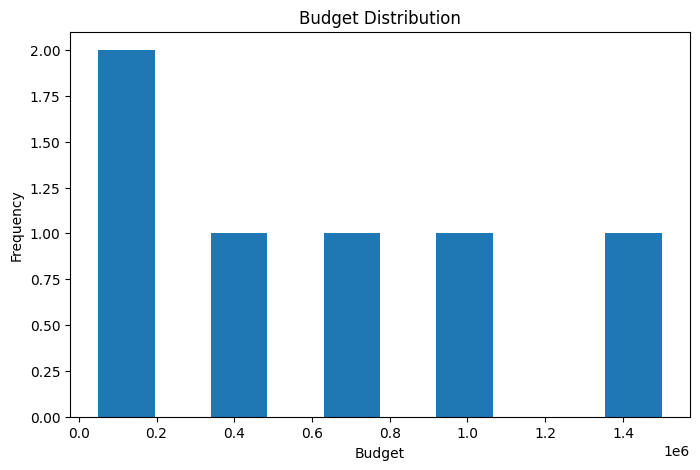

In [32]:
import pandas as pd
import matplotlib.pyplot as plt

# Load dataset

df = pd.read_csv('data/event_data.csv')

# Show first rows
print(df.head())

# Basic information
print(df.info())

# Statistics
print(df.describe())

# Plot budget distribution

plt.figure(figsize=(8,5))
plt.hist(df['budget'])
plt.xlabel('Budget')
plt.ylabel('Frequency')
plt.title('Budget Distribution')
plt.show()

In [33]:
import pandas as pd
import joblib

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder
from sklearn.ensemble import RandomForestRegressor
from sklearn.multioutput import MultiOutputRegressor

# Load dataset

df = pd.read_csv('data/event_data.csv')

# Convert text labels into numbers

encoder = LabelEncoder()

df['event_type'] = encoder.fit_transform(df['event_type'])

# Input features

X = df[['event_type', 'guests', 'budget']]

# Output targets
y = df[[
    'venue',
    'catering',
    'decoration',
    'photography',
    'entertainment'
]]

# Split data

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42
)
# Create model

model = MultiOutputRegressor(
    RandomForestRegressor()
)

# Train model

model.fit(X_train, y_train)

# Save model

joblib.dump(model, 'models/budget_model.pkl')
joblib.dump(encoder, 'models/event_encoder.pkl')

print("ML model trained successfully")

ML model trained successfully


In [34]:
import joblib
import pandas as pd

# Load saved model

model = joblib.load('models/budget_model.pkl')
encoder = joblib.load('models/event_encoder.pkl')

# Example input

event_type = 'Wedding'
guests = 300
budget = 1000000

# Convert event type into numeric format

encoded_type = encoder.transform([event_type])[0]

# Create dataframe

input_data = pd.DataFrame([
    [encoded_type, guests, budget]
], columns=['event_type', 'guests', 'budget'])

# Predict

prediction = model.predict(input_data)

print("Predicted Budget Allocation")
print("Venue:", int(prediction[0][0]))
print("Catering:", int(prediction[0][1]))
print("Decoration:", int(prediction[0][2]))
print("Photography:", int(prediction[0][3]))
print("Entertainment:", int(prediction[0][4]))

Predicted Budget Allocation
Venue: 261000
Catering: 236700
Decoration: 132450
Photography: 89220
Entertainment: 162380


In [35]:
wedding_guide = """
Wedding planning should begin at least 6 months before the event.
Book venue early.
Hire photographers and caterers in advance.
Decoration themes should match venue style.
"""

corporate_guide = """
Corporate events require scheduling and formal planning.
Focus on networking and professional branding.
Audio systems and presentations are important.
"""

birthday_guide = """
Birthday events are usually budget-friendly.
Entertainment and food are key attractions.
Themes improve guest experience.
"""
# Save files

with open('data/event_guides/wedding.txt', 'w') as f:
    f.write(wedding_guide)

with open('data/event_guides/corporate.txt', 'w') as f:
    f.write(corporate_guide)

with open('data/event_guides/birthday.txt', 'w') as f:
    f.write(birthday_guide)

print("Knowledge files created")

Knowledge files created


In [36]:
from langchain_community.document_loaders import TextLoader
from langchain_text_splitters import CharacterTextSplitter
from langchain_community.vectorstores import FAISS
from langchain_huggingface import HuggingFaceEmbeddings

# Load text files manually

documents = []

files = [
    'data/event_guides/wedding.txt',
    'data/event_guides/corporate.txt',
    'data/event_guides/birthday.txt'
]

for file in files:
    loader = TextLoader(file)
    documents.extend(loader.load())

print("Documents Loaded:", len(documents))

# Split documents into chunks

splitter = CharacterTextSplitter(
    chunk_size=200,
    chunk_overlap=20
)

texts = splitter.split_documents(documents)

print("Text Chunks:", len(texts))

# Create embeddings

embeddings = HuggingFaceEmbeddings(
    model_name='sentence-transformers/all-MiniLM-L6-v2'
)

# Create FAISS vector database

vectorstore = FAISS.from_documents(
    texts,
    embeddings
)

# Save vector database

vectorstore.save_local('models/vector_store')

print("✅ Vector Database Created Successfully")

Documents Loaded: 3
Text Chunks: 3


Loading weights:   0%|          | 0/103 [00:00<?, ?it/s]

BertModel LOAD REPORT from: sentence-transformers/all-MiniLM-L6-v2
Key                     | Status     |  | 
------------------------+------------+--+-
embeddings.position_ids | UNEXPECTED |  | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.


✅ Vector Database Created Successfully


In [37]:
from langchain_community.vectorstores import FAISS
from langchain_huggingface import HuggingFaceEmbeddings

# Load embeddings

embeddings = HuggingFaceEmbeddings(
    model_name='sentence-transformers/all-MiniLM-L6-v2'
)

# Load vector database

vectorstore = FAISS.load_local(
    'models/vector_store',
    embeddings,
    allow_dangerous_deserialization=True
)

# User query

query = 'How should I plan a wedding?'

# Retrieve similar documents

docs = vectorstore.similarity_search(query)

# Print answer

print(docs[0].page_content)

Loading weights:   0%|          | 0/103 [00:00<?, ?it/s]

BertModel LOAD REPORT from: sentence-transformers/all-MiniLM-L6-v2
Key                     | Status     |  | 
------------------------+------------+--+-
embeddings.position_ids | UNEXPECTED |  | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.


Wedding planning should begin at least 6 months before the event.
Book venue early.
Hire photographers and caterers in advance.
Decoration themes should match venue style.


In [38]:
import joblib
import pandas as pd

# Load model

model = joblib.load('models/budget_model.pkl')
encoder = joblib.load('models/event_encoder.pkl')

# Budget Agent Function

def predict_budget(event_type, guests, budget):

    # Encode text label
    encoded_type = encoder.transform([event_type])[0]

    # Create input dataframe
    input_df = pd.DataFrame([
        [encoded_type, guests, budget]
    ], columns=['event_type', 'guests', 'budget'])

    # Predict
    prediction = model.predict(input_df)[0]

    # Return result
    return {
        'venue': int(prediction[0]),
        'catering': int(prediction[1]),
        'decoration': int(prediction[2]),
        'photography': int(prediction[3]),
        'entertainment': int(prediction[4])
    }

# Test
print(predict_budget('Wedding', 300, 1000000))

{'venue': 261000, 'catering': 236700, 'decoration': 132450, 'photography': 89220, 'entertainment': 162380}


In [39]:
from langchain_community.vectorstores import FAISS
from langchain_huggingface import HuggingFaceEmbeddings

# Load embeddings

embeddings = HuggingFaceEmbeddings(
    model_name='sentence-transformers/all-MiniLM-L6-v2'
)

# Load vector database

vectorstore = FAISS.load_local(
    'models/vector_store',
    embeddings,
    allow_dangerous_deserialization=True
)

# Research Agent

def research_agent(query):

    docs = vectorstore.similarity_search(query)

    return docs[0].page_content

# Test

print(research_agent('Best wedding planning strategy'))

Loading weights:   0%|          | 0/103 [00:00<?, ?it/s]

BertModel LOAD REPORT from: sentence-transformers/all-MiniLM-L6-v2
Key                     | Status     |  | 
------------------------+------------+--+-
embeddings.position_ids | UNEXPECTED |  | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.


Wedding planning should begin at least 6 months before the event.
Book venue early.
Hire photographers and caterers in advance.
Decoration themes should match venue style.


In [40]:
# Planner Agent

def planner_agent(event_type, city, budget, guests):

    # Step 1 — Budget Prediction

    budget_plan = predict_budget(
        event_type,
        guests,
        budget
    )

    # Step 2 — Retrieve Knowledge

    knowledge = research_agent(
        f'How to plan {event_type}'
    )

    # Step 3 — Create Timeline

    timeline = [
        '6 Months Before → Book venue',
        '5 Months Before → Hire caterers',
        '4 Months Before → Confirm decorations',
        '3 Months Before → Photography booking',
        '1 Month Before → Vendor confirmation',
        'Event Day → Execute event'
    ]

    # Final Output

    result = {
        'event_type': event_type,
        'city': city,
        'total_budget': budget,
        'guest_count': guests,
        'budget_breakdown': budget_plan,
        'event_knowledge': knowledge,
        'timeline': timeline
    }

    return result

# Test Planner Agent

plan = planner_agent(
        'Wedding',
    'Bangalore',
    1000000,
    300
)

print(plan)

{'event_type': 'Wedding', 'city': 'Bangalore', 'total_budget': 1000000, 'guest_count': 300, 'budget_breakdown': {'venue': 261000, 'catering': 236700, 'decoration': 132450, 'photography': 89220, 'entertainment': 162380}, 'event_knowledge': 'Wedding planning should begin at least 6 months before the event.\nBook venue early.\nHire photographers and caterers in advance.\nDecoration themes should match venue style.', 'timeline': ['6 Months Before → Book venue', '5 Months Before → Hire caterers', '4 Months Before → Confirm decorations', '3 Months Before → Photography booking', '1 Month Before → Vendor confirmation', 'Event Day → Execute event']}


In [41]:
from fastapi import FastAPI
import uvicorn

# Create API app

app = FastAPI()

# Home Route

@app.get('/')
def home():
    return {'message': 'Festiva Planner AI Running'}

# Event Planning Route

@app.post('/plan-event')
def plan_event(data: dict):

    result = planner_agent(
        data['event_type'],
        data['city'],
        data['budget'],
        data['guests']
    )

    return result

print('FastAPI app ready')

FastAPI app ready


In [42]:
# Example User Input

user_event_type = 'Wedding'
user_city = 'Bangalore'
user_budget = 1000000
user_guests = 300

# Generate AI Event Plan

final_plan = planner_agent(
    user_event_type,
    user_city,
    user_budget,
    user_guests
)

# Display Output

print('\n=========== FESTIVA PLANNER AI ===========\n')

print('Event Type:', final_plan['event_type'])
print('City:', final_plan['city'])
print('Budget:', final_plan['total_budget'])
print('Guests:', final_plan['guest_count'])

print('\n===== Budget Breakdown =====')

for key, value in final_plan['budget_breakdown'].items():
    print(f'{key}: ₹{value}')

print('\n===== Event Knowledge =====')
print(final_plan['event_knowledge'])

print('\n===== Timeline =====')

for step in final_plan['timeline']:
    print(step)


=========== FESTIVA PLANNER AI ===========

Event Type: Wedding
City: Bangalore
Budget: 1000000
Guests: 300

===== Budget Breakdown =====
venue: ₹261000
catering: ₹236700
decoration: ₹132450
photography: ₹89220
entertainment: ₹162380

===== Event Knowledge =====
Wedding planning should begin at least 6 months before the event.
Book venue early.
Hire photographers and caterers in advance.
Decoration themes should match venue style.

===== Timeline =====
6 Months Before → Book venue
5 Months Before → Hire caterers
4 Months Before → Confirm decorations
3 Months Before → Photography booking
1 Month Before → Vendor confirmation
Event Day → Execute event
